<a href="https://colab.research.google.com/github/Adossi-design/Malaria-Diagnosis/blob/main/Elvin_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Problem Framing and Literature Review

### Why malaria diagnosis is worth automating

The WHO reported over 249 million malaria cases and more than 600,000 deaths in 2022, most of those in children under five in Africa (WHO, 2023). Diagnosing malaria by microscopy is accurate when done well but trained technicians are scarce where malaria is most common. Patients wait and treatment gets delayed. An automated system that screens smears with high sensitivity wouldnt replace technicians but it could let one expert review flagged cases instead of every single slide. Thats the practical motivation here.

### How CNNs got here

LeCun et al. (1998) introduced convolutional neural networks for handwritten digit recognition. The key idea was that the network learns its own visual features from raw pixels using backpropagation instead of relying on hand-engineered features. That made CNNs general-purpose image classifiers once enough compute and data became available. Simonyan and Zisserman (2014) pushed the architecture deeper with VGG16 using stacks of small 3x3 convolutions. He et al. (2016) introduced residual connections in ResNet which let networks reach 50+ layers without the gradient vanishing during training. Sandler et al. (2018) went the other direction with MobileNetV2, designing an efficient architecture that hits competitive accuracy with way fewer parameters - useful when the target deployment is a clinic with limited hardware.

### Transfer learning for medical images

Pan and Yang (2010) defined transfer learning as using knowledge gained in one domain to solve a problem in another. In medical imaging this matters because labeled datasets tend to be small since annotating images requires expert time and is expensive. Tajbakhsh et al. (2016) showed that fine-tuning pretrained CNNs beats training from scratch on medical tasks, especially when the dataset has fewer than 50,000 images. The NIH malaria dataset has about 27,000 which puts it in the range where transfer learning is the right call.

### Prior malaria work

Rajaraman et al. (2018) tested several pretrained CNNs on this same dataset and reported over 95% accuracy with VGG16 as a feature extractor. Their work is the closest reference point for what were doing. They also found that fine-tuning beats pure feature extraction which is why every member running a pretrained model in our group includes progressive unfreezing experiments rather than just using the backbone frozen.

### Regularization

Srivastava et al. (2014) introduced dropout which randomly zeroes out a fraction of activations during training so neurons cant rely on specific co-adaptations. Ioffe and Szegedy (2015) introduced batch normalization which standardizes activations across each mini-batch and speeds up training while acting as a mild regularizer. Both show up in our baseline and advanced CNN designs.

### What this project adds

Most existing work uses a single architecture. We compare five - two from-scratch CNNs and three pretrained models - under the same dataset, split, and evaluation protocol. That makes the architectural differences directly comparable rather than confounded by different experimental setups.

### References

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. CVPR, 770-778.
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. ICML, 448-456.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.
- Pan, S. J., & Yang, Q. (2010). A survey on transfer learning. IEEE TKDE, 22(10), 1345-1359.
- Rajaraman, S., Antani, S. K., Poostchi, M., et al. (2018). Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images. PeerJ, 6, e4568.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. CVPR, 4510-4520.
- Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. ICLR.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. JMLR, 15(1), 1929-1958.
- Tajbakhsh, N., Shin, J. Y., Gurudu, S. R., et al. (2016). Convolutional neural networks for medical image analysis: Full training or fine tuning? IEEE TMI, 35(5), 1299-1312.
- WHO. (2023). World Malaria Report 2023. World Health Organization.

## Configuration

Mount Google Drive for saving trained models and check that the runtime is using a GPU. If the GPU check prints nothing, switch the runtime to T4 GPU before continuing.

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
saved_models


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Imports and Constants

Shared libraries and configuration used by every model. The seed, image size, batch size, class names, and epoch budget are fixed here so everyones results are directly comparable.

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Dataset Preparation

### Download

The NIH malaria dataset is fetched from the National Library of Medicine. Only runs once - after the cell_images folder exists it gets skipped.

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-08 18:50:25--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.163.189.96, 3.163.189.83, 3.163.189.93, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.163.189.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   261MB/s    in 1.3s    

2026-06-08 18:50:26 (261 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


### Additional Imports

Libraries used across the pretrained model sections. Each pretrained model imports its own preprocess_input so it gets the normalization it was trained with instead of generic rescaling.

In [6]:
import warnings
import numpy as np
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dropout, BatchNormalization,
                                      GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_v2_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED       = 42
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
CLASSES    = ['Parasitized', 'Uninfected']
EPOCHS_MAX = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Additional libraries loaded.')

Additional libraries loaded.


### Train / Test Split

Splits each class folder 80/20 with the shared seed. Because every member uses the same seed we all train and test on the exact same images which is what makes the consolidated results table meaningful. The test set here doubles as the validation set during training - thats a known limitation we note in the discussion.

In [7]:
def create_splits(rebuild=False):
    if os.path.exists(training_path) and not rebuild:
        print('Folders already exist. Set rebuild=True to redo.')
        for sp in ['train', 'test']:
            for cls in CLASSES:
                print(f'  {sp}/{cls}: {len(os.listdir(os.path.join(sp, cls))):,}')
        return
    for sp in ['train', 'test']:
        if os.path.exists(sp): shutil.rmtree(sp)
    for sp in ['train', 'test']:
        for cls in CLASSES:
            os.makedirs(os.path.join(sp, cls), exist_ok=True)
    for cls in CLASSES:
        src   = os.path.join(cell_images_dir, cls)
        files = [f for f in os.listdir(src) if f.endswith('.png')]
        random.shuffle(files)
        n = len(files); n_tr = int(n * 0.80)
        for sp, fl in [('train', files[:n_tr]), ('test', files[n_tr:])]:
            for f in fl:
                shutil.copy(os.path.join(src, f), os.path.join(sp, cls, f))
            print(f'  {sp}/{cls}: {len(fl):,}')
    print('Split complete.')

create_splits(rebuild=False)

  train/Parasitized: 11,023
  test/Parasitized: 2,756
  train/Uninfected: 11,023
  test/Uninfected: 2,756
Split complete.


### Data Generators

The shared generator factory supports two modes: generic 1/255 rescaling for the from-scratch CNNs (Adossi, Nehemie), or a model-specific preprocessing_function for the pretrained models (Berissa, Elvin, Gabriel). Augmentation is optional and only applied to the training stream.

In [8]:
def make_generators(batch_size=64, aug=False, preprocess_fn=None):
    if preprocess_fn is not None:
        aug_cfg   = dict(preprocessing_function=preprocess_fn, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(preprocessing_function=preprocess_fn)
        te_cfg    = dict(preprocessing_function=preprocess_fn)
    else:
        aug_cfg   = dict(rescale=1./255, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(rescale=1./255)
        te_cfg    = dict(rescale=1./255)
    kw = dict(target_size=IMG_SIZE, batch_size=batch_size, class_mode='binary')
    tr = ImageDataGenerator(**(aug_cfg if aug else plain_cfg))
    te = ImageDataGenerator(**te_cfg)
    tg = tr.flow_from_directory(training_path, seed=SEED, **kw)
    eg = te.flow_from_directory(testing_path, shuffle=False, **kw)
    return tg, eg

train_gen, test_gen = make_generators()
print('Class indices:', train_gen.class_indices)
print(f'Train: {train_gen.n:,} | Test: {test_gen.n:,}')

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Train: 22,046 | Test: 5,512


### Sample Images

Quick visual sanity check - twelve cells from the training set, six per class. Parasitized cells typically show small dark Plasmodium rings inside the cytoplasm while uninfected cells look uniformly stained. If the labels look swapped or the images look broken something is wrong with the pipeline.

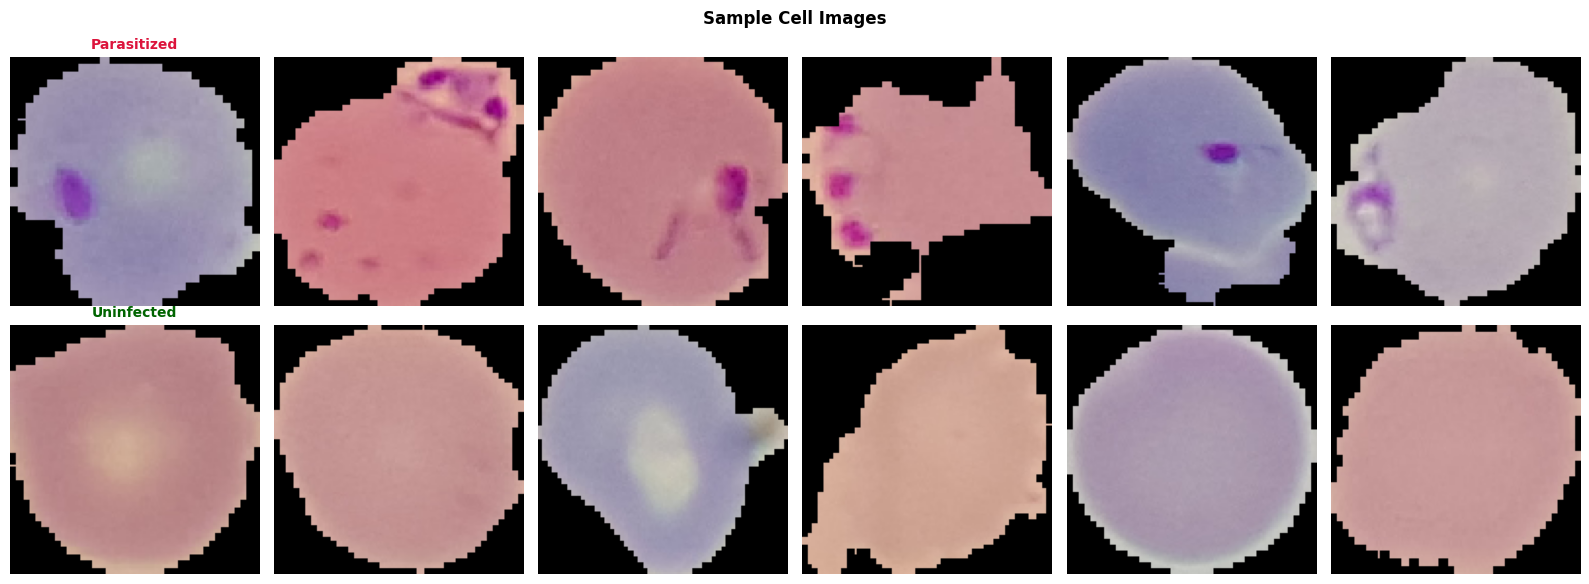

In [9]:
cls_names = list(train_gen.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Cell Images', fontsize=12, fontweight='bold')
imgs, lbls = next(train_gen)
shown = {0:0, 1:0}
for img, lbl in zip(imgs, lbls):
    lbl = int(lbl); col = shown[lbl]
    if col < 6:
        axes[lbl, col].imshow(img); axes[lbl, col].axis('off')
        if col == 0:
            axes[lbl, col].set_title(cls_names[lbl], fontsize=10,
                color='crimson' if lbl==0 else 'darkgreen', fontweight='bold')
        shown[lbl] += 1
    if shown[0]==6 and shown[1]==6: break
pyplot.tight_layout(); pyplot.show()

### Evaluation Utilities

Three helpers shared across all five models:

- plot_learning_curves - train vs test accuracy and loss over epochs, used to spot overfitting
- evaluate_model - runs the model on the test generator, prints metrics (accuracy, precision, recall, F1, AUC), draws confusion matrix and ROC curve
- results_table - formats per-model results into the shared table layout
- get_callbacks - EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau, all watching val_loss

evaluate_model treats the Parasitized class as positive in the ROC curve because in a medical screening setting sensitivity to infection is the metric that matters most.

In [10]:
def plot_learning_curves(history, name='Model'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    ep = range(1, len(acc)+1)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{name} -- Learning Curves', fontsize=13, fontweight='bold')
    a1.plot(ep, acc, 'b-o', ms=3, label='Train')
    a1.plot(ep, val_acc, 'r-o', ms=3, label='Test')
    a1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, loss, 'b-o', ms=3, label='Train')
    a2.plot(ep, val_loss, 'r-o', ms=3, label='Test')
    a2.set(title='Loss', xlabel='Epoch', ylabel='Binary Cross-Entropy')
    a2.legend(); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_curves.png', dpi=150, bbox_inches='tight')
    pyplot.show()


def evaluate_model(model, gen, name='Model', threshold=0.5):
    gen.reset()
    probs  = model.predict(gen, verbose=0).flatten()
    yp     = (probs >= threshold).astype(int)
    yt     = gen.classes
    cnames = list(gen.class_indices.keys())
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    fpr, tpr, _ = roc_curve(yt, 1-probs, pos_label=0)
    roc_auc = auc(fpr, tpr)
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC       : {roc_auc:.4f}')
    print(f'{"="*50}')
    print(classification_report(yt, yp, target_names=cnames))
    cm = confusion_matrix(yt, yp)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a1,
                xticklabels=cnames, yticklabels=cnames)
    a1.set(title=f'{name} -- Confusion Matrix',
           xlabel='Predicted', ylabel='True')
    tn, fp, fn, tp = cm.ravel()
    a1.text(0.5, -0.13, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
            transform=a1.transAxes, ha='center', fontsize=9, color='navy')
    a2.plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={roc_auc:.4f}')
    a2.fill_between(fpr, tpr, alpha=0.07, color='darkorange')
    a2.plot([0,1],[0,1],'navy',lw=1.5,ls='--',label='Random (AUC=0.5)')
    a2.set(xlim=[0,1], ylim=[0,1.02], title=f'{name} -- ROC/AUC',
           xlabel='False Positive Rate', ylabel='True Positive Rate')
    a2.legend(loc='lower right'); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_eval.png', dpi=150, bbox_inches='tight')
    pyplot.show()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)


def results_table(experiments):
    hdr = (f"{'Exp':>4} | {'Description':<35} | "
           f"{'Acc':>6} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'AUC':>6}")
    sep = '='*len(hdr)
    print(f'\n{sep}\n{hdr}\n{sep}')
    for e in experiments:
        print(f"{e['id']:>4} | {e['desc']:<35} | {e['accuracy']:.4f} | "
              f"{e['precision']:.4f} | {e['recall']:.4f} | "
              f"{e['f1']:.4f} | {e['auc']:.4f}")
    print(sep)


def get_callbacks(name):
    os.makedirs('saved_models', exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f'saved_models/{name}.keras',
                                  monitor='val_accuracy', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)
    ]

print('Evaluation utilities ready.')

Evaluation utilities ready.


In [11]:
import os

# Save to Google Drive so models survive Colab disconnections.
# When the connection drops, re-run from the top — already-trained
# experiments load from Drive and are skipped automatically.
SAVE_DIR = '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

def train_or_load(name, model, tg, eg):
    path = os.path.join(SAVE_DIR, name + '.keras')
    if os.path.exists(path):
        print(f'  Skipping {name} -- loading saved weights from {path}')
        model = tf.keras.models.load_model(path)
        return model, None
    history = model.fit(
        tg, epochs=EPOCHS_MAX, validation_data=eg,
        callbacks=get_callbacks(name), verbose=1
    )
    model.save(path)
    print(f'  Saved {name} -> {path}')
    return model, history

In [12]:
def make_resnet_generators(batch_size=64, aug=False):
    return make_generators(batch_size=batch_size, aug=aug, preprocess_fn=resnet50_preprocess)

print('make_resnet_generators ready.')

make_resnet_generators ready.


---
## ResNet50 Pre-trained Model

**Elvin Cyubahiro**

**How ResNet50 works and why I kept BatchNorm frozen**

ResNet50 has 50 layers and uses skip connections to let gradients pass through layers without disappearing which is what makes training a network this deep actually work well. I used transfer learning by removing the original output and adding my own head with GlobalAveragePooling2D, a Dense layer with 256 neurons, Dropout at 0.5 and a sigmoid output. One important design choice was to keep all BatchNormalization layers frozen the whole time even when unfreezing the convolutional layers around them because if I let them update on our small dataset they would overwrite the statistics learned from ImageNet and break the normalization entirely.

| Exp | What changes | What I expect to see |
|-----|-------------|---------------------|
| 1 | All layers frozen, only the head trains | Baseline from pure feature extraction - should hit ~94% based on Rajaraman et al. |
| 2 | Unfreeze last 10 layers, lr=1e-5 | Small accuracy gain from light fine-tuning |
| 3 | Unfreeze last 30 layers, lr=1e-5 | More capacity - should beat Exp 2 |
| 4 | Unfreeze last 50 layers, lr=1e-5 | Either keeps improving or starts overfitting |
| 5 | Frozen backbone + augmentation | Either helps or hurts since fixed features cant adapt to harder task |
| 6 | 30 layers + augmentation, lr=1e-5 | Best of both - fine-tuning to adapt, augmentation to regularize |
| 7 | 10 layers, ultra-low lr=5e-6 | Tests whether smaller updates change the outcome at same depth |

The arc isolates one variable at a time. Exp 1-4 isolate fine-tuning depth. Exp 5 isolates augmentation on a fixed backbone. Exp 6 combines the best depth with augmentation. Exp 7 probes learning rate sensitivity.

In [13]:
def build_resnet50(unfreeze_last=0, lr=1e-4):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
    base.trainable = False
    if unfreeze_last > 0:
        for layer in base.layers[-unfreeze_last:]:
            if not isinstance(layer, BatchNormalization):
                layer.trainable = True
    inp = Input(shape=(128,128,3))
    x   = base(inp, training=False)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='ResNet50_TL')
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_resnet50().summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### E_exp1 - ResNet50 fully frozen, GAP head

This is my transfer learning baseline where the entire ResNet50 backbone is frozen and only the head trains and I expected the pretrained features to give decent accuracy but the model might underfit a little since ImageNet features were not built for the staining patterns you see in malaria microscopy images.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 77s 174ms/step - accuracy: 0.8480 - loss: 0.3601 - val_accuracy: 0.9147 - val_loss: 0.2321 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 45s 130ms/step - accuracy: 0.9039 - loss: 0.2406 - val_accuracy: 0.9229 - val_loss: 0.2158 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.9146 - loss: 0.2190 - val_accuracy: 0.9267 - val_loss: 0.2036 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.9200 - loss: 0.2020 - val_accuracy: 0.9309 - val_loss: 0.1883 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.9257 - loss: 0.1941 - val_accuracy: 0.9345 - val_loss: 0.1782 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9302 - loss: 0.1843 - val_accuracy: 0.9341 - val_lo

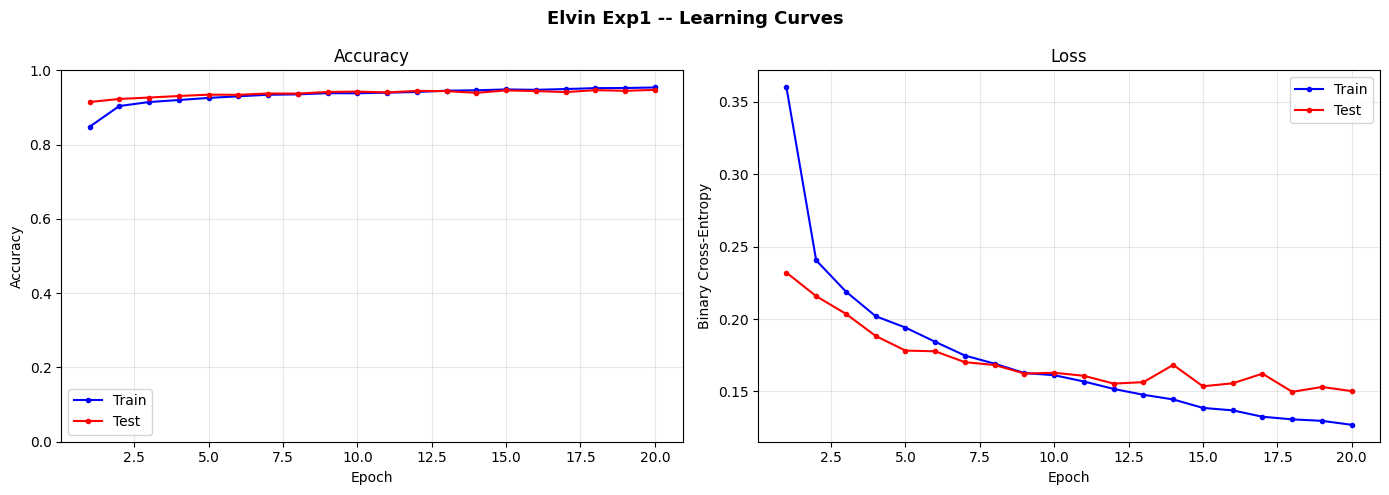


  Elvin Exp1
  Accuracy  : 0.9467
  Precision : 0.9480
  Recall    : 0.9452
  F1-Score  : 0.9466
  AUC       : 0.9861
              precision    recall  f1-score   support

 Parasitized       0.95      0.95      0.95      2756
  Uninfected       0.95      0.95      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



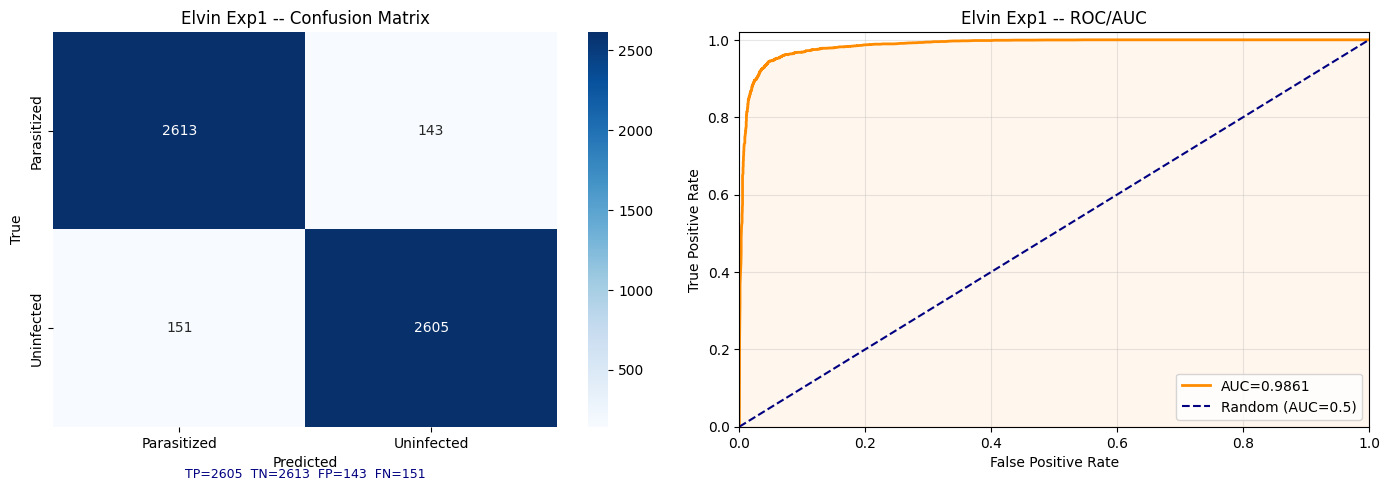

In [14]:
tg, eg = make_resnet_generators()
e1 = build_resnet50(0, 1e-4)
e1, he1 = train_or_load('E_exp1', e1, tg, eg)
if he1: plot_learning_curves(he1, 'Elvin Exp1')
re1 = evaluate_model(e1, eg, 'Elvin Exp1')

### E_exp2 - Unfreeze last 10 layers, lr=1e-5

I unfroze the last 10 layers of ResNet50 while keeping all BatchNormalization layers frozen and I used a learning rate of 0.00001 to make sure the pretrained weights change slowly and carefully without getting overwritten by updates that are too large.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 81s 178ms/step - accuracy: 0.8338 - loss: 0.3878 - val_accuracy: 0.9133 - val_loss: 0.2207 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.9147 - loss: 0.2189 - val_accuracy: 0.9338 - val_loss: 0.1839 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 121ms/step - accuracy: 0.9301 - loss: 0.1843 - val_accuracy: 0.9367 - val_loss: 0.1799 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.9389 - loss: 0.1630 - val_accuracy: 0.9430 - val_loss: 0.1650 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - accuracy: 0.9465 - loss: 0.1454 - val_accuracy: 0.9461 - val_loss: 0.1582 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step - accuracy: 0.9497 - loss: 0.1357 - val_accuracy: 0.9459 - val_loss: 0.1551 - learning_rate: 1.0000e-05
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 11

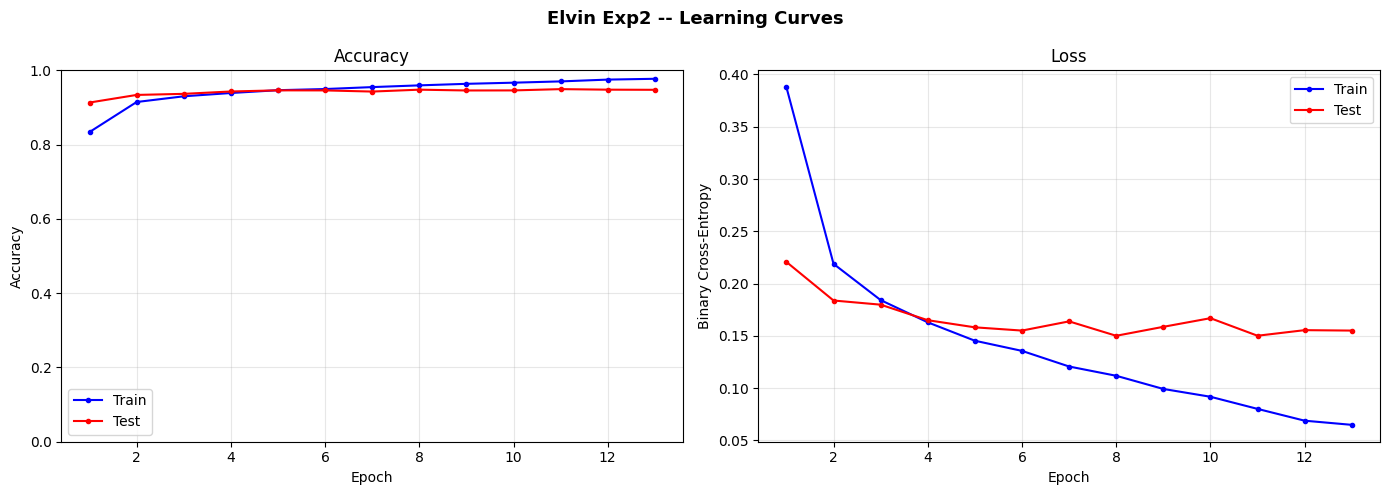


  Elvin Exp2
  Accuracy  : 0.9479
  Precision : 0.9433
  Recall    : 0.9532
  F1-Score  : 0.9482
  AUC       : 0.9869
              precision    recall  f1-score   support

 Parasitized       0.95      0.94      0.95      2756
  Uninfected       0.94      0.95      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



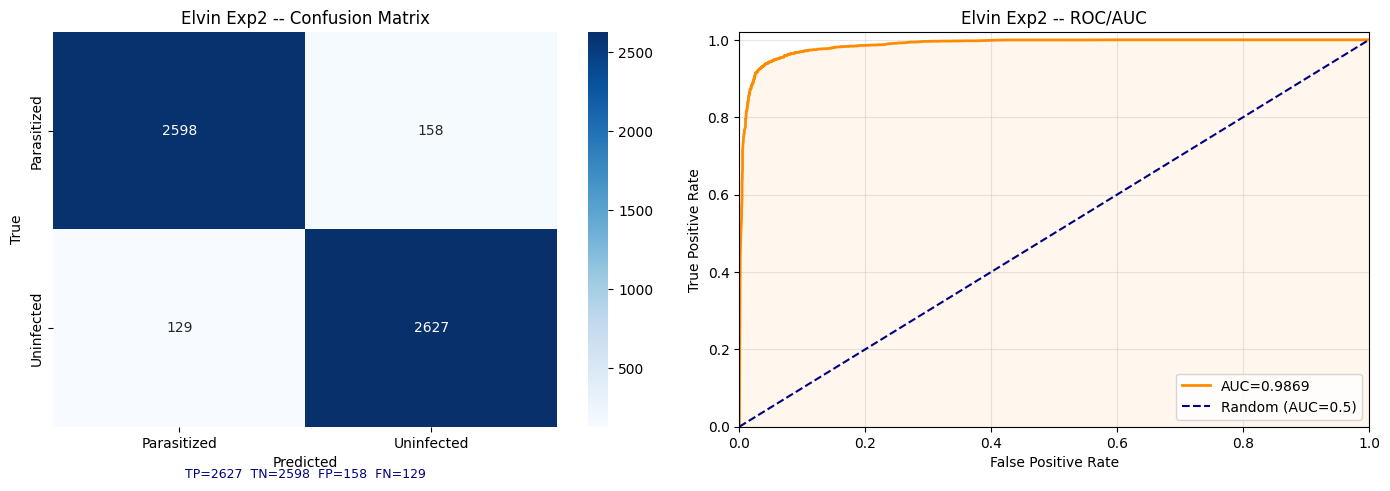

In [15]:
e2 = build_resnet50(10, 1e-5)
e2, he2 = train_or_load('E_exp2', e2, tg, eg)
if he2: plot_learning_curves(he2, 'Elvin Exp2')
re2 = evaluate_model(e2, eg, 'Elvin Exp2')

### E_exp3 - Unfreeze last 30 layers, lr=1e-5

I unfroze 30 layers this time which covers more of the final residual stages and having more layers free to adapt means the model can shift more of its features toward the malaria image domain so I expected better results than Experiment 2.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 81s 179ms/step - accuracy: 0.8702 - loss: 0.3093 - val_accuracy: 0.9370 - val_loss: 0.1750 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - accuracy: 0.9467 - loss: 0.1462 - val_accuracy: 0.9478 - val_loss: 0.1512 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 129ms/step - accuracy: 0.9570 - loss: 0.1169 - val_accuracy: 0.9546 - val_loss: 0.1340 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9681 - loss: 0.0886 - val_accuracy: 0.9559 - val_loss: 0.1392 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.9756 - loss: 0.0683 - val_accuracy: 0.9552 - val_loss: 0.1434 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9844 - loss: 0.0478
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/ste

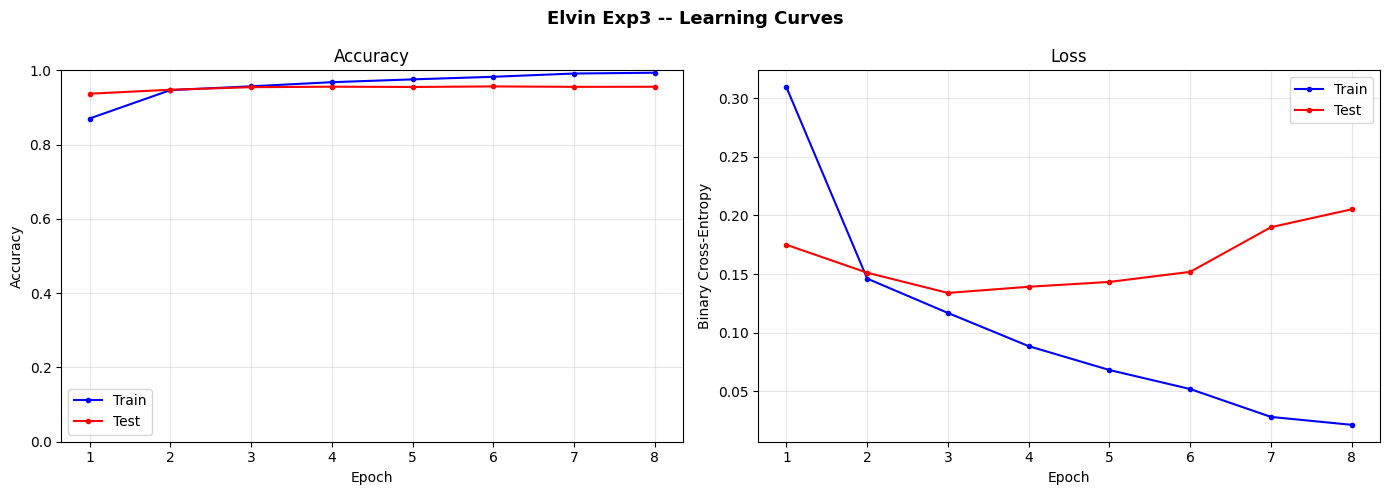


  Elvin Exp3
  Accuracy  : 0.9546
  Precision : 0.9459
  Recall    : 0.9644
  F1-Score  : 0.9551
  AUC       : 0.9892
              precision    recall  f1-score   support

 Parasitized       0.96      0.94      0.95      2756
  Uninfected       0.95      0.96      0.96      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



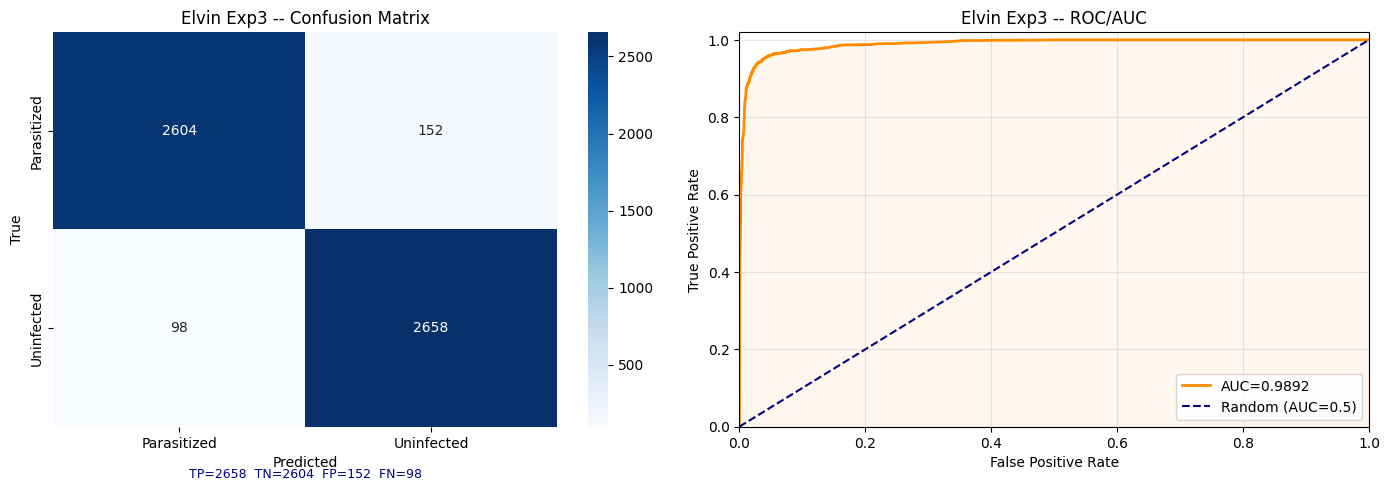

In [16]:
e3 = build_resnet50(30, 1e-5)
e3, he3 = train_or_load('E_exp3', e3, tg, eg)
if he3: plot_learning_curves(he3, 'Elvin Exp3')
re3 = evaluate_model(e3, eg, 'Elvin Exp3')

### E_exp4 - Unfreeze last 50 layers, lr=1e-5

I unfroze 50 layers here which is the deepest fine-tuning I tried and the risk of catastrophic forgetting is highest at this point so I was watching the validation numbers carefully to see whether going this deep helped or started to hurt performance.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 91s 194ms/step - accuracy: 0.8902 - loss: 0.2749 - val_accuracy: 0.9528 - val_loss: 0.1420 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 49s 141ms/step - accuracy: 0.9560 - loss: 0.1247 - val_accuracy: 0.9583 - val_loss: 0.1258 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 45s 132ms/step - accuracy: 0.9659 - loss: 0.0926 - val_accuracy: 0.9595 - val_loss: 0.1199 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.9746 - loss: 0.0699 - val_accuracy: 0.9621 - val_loss: 0.1189 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.9823 - loss: 0.0503 - val_accuracy: 0.9601 - val_loss: 0.1308 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9878 - loss: 0.0334 - val_accuracy: 0.9521 - val_loss: 0.1720 - learning_rate: 1.0000e-05
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 100

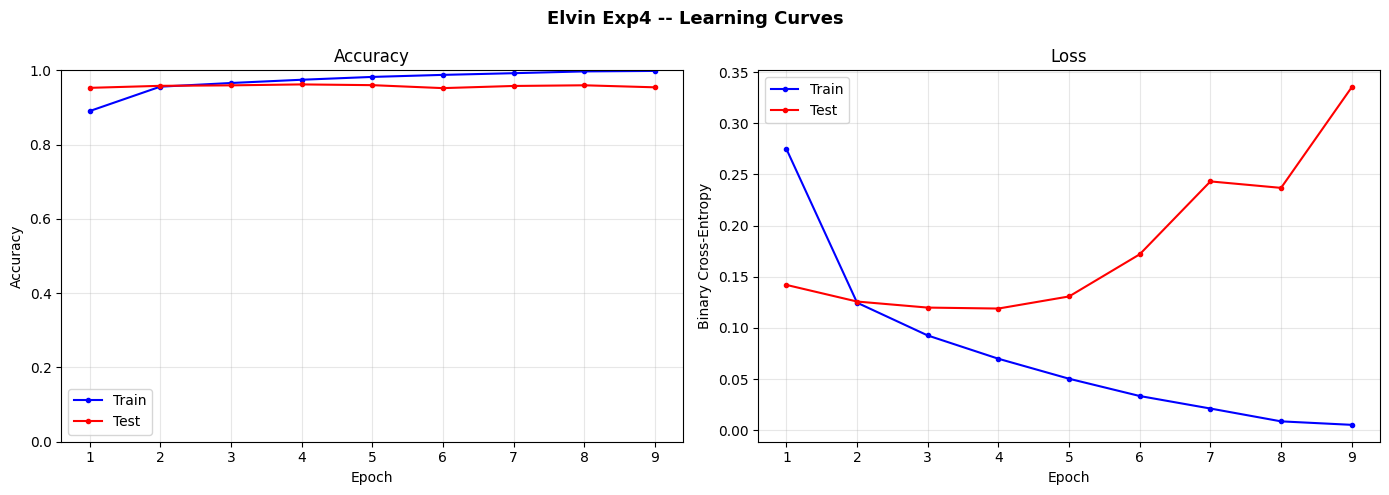


  Elvin Exp4
  Accuracy  : 0.9621
  Precision : 0.9560
  Recall    : 0.9688
  F1-Score  : 0.9623
  AUC       : 0.9920
              precision    recall  f1-score   support

 Parasitized       0.97      0.96      0.96      2756
  Uninfected       0.96      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



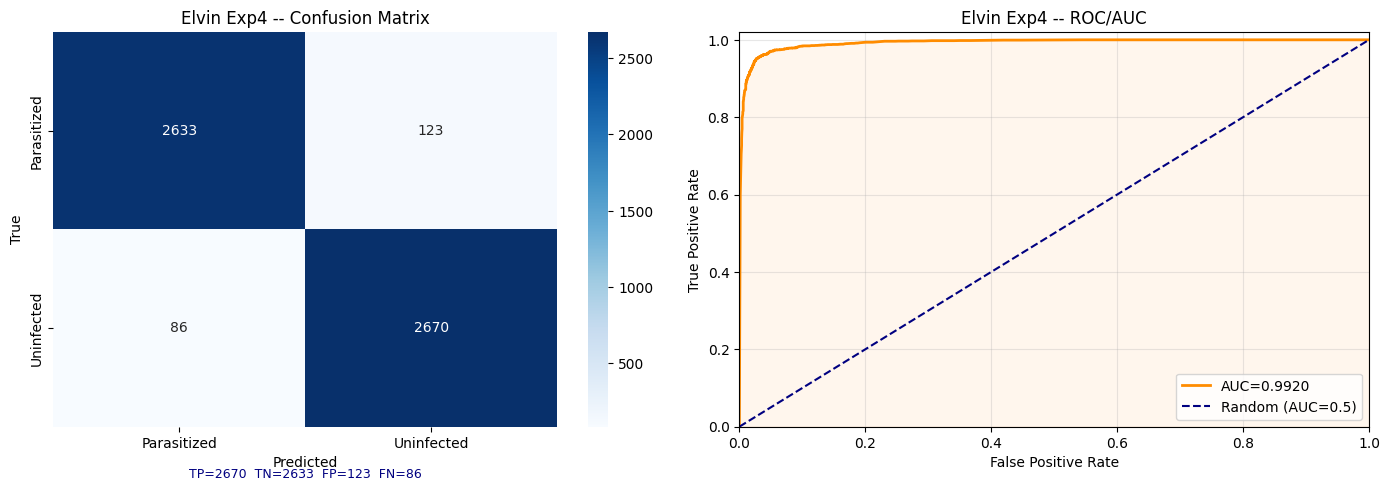

In [17]:
e4 = build_resnet50(50, 1e-5)
e4, he4 = train_or_load('E_exp4', e4, tg, eg)
if he4: plot_learning_curves(he4, 'Elvin Exp4')
re4 = evaluate_model(e4, eg, 'Elvin Exp4')

### E_exp5 - Fully frozen + data augmentation

I kept the backbone completely frozen here and only added augmentation to see whether giving the head more variety in training images alone is enough to improve generalization without making any changes to the backbone weights at all.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 160s 422ms/step - accuracy: 0.8343 - loss: 0.3996 - val_accuracy: 0.8808 - val_loss: 0.2805 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 126s 364ms/step - accuracy: 0.8898 - loss: 0.2708 - val_accuracy: 0.8984 - val_loss: 0.2437 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 122s 353ms/step - accuracy: 0.9042 - loss: 0.2444 - val_accuracy: 0.9058 - val_loss: 0.2304 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 119s 345ms/step - accuracy: 0.9118 - loss: 0.2294 - val_accuracy: 0.8832 - val_loss: 0.2664 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 121s 350ms/step - accuracy: 0.9170 - loss: 0.2152 - val_accuracy: 0.9097 - val_loss: 0.2150 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 121s 350ms/step - accuracy: 0.9168 - loss: 0.2147 - val_accuracy: 0.9213 - 

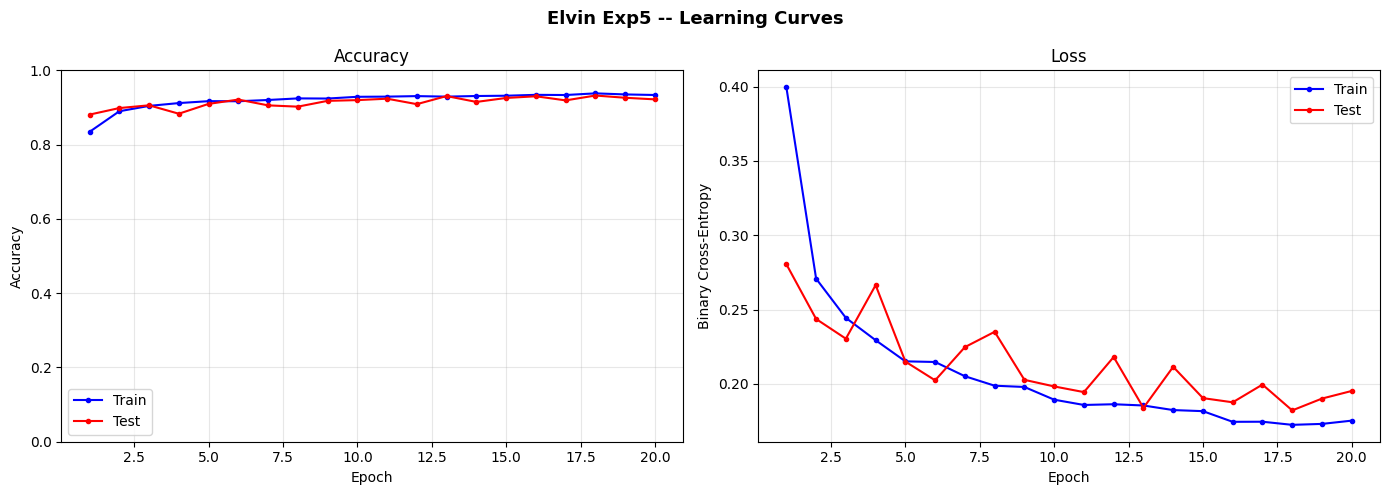


  Elvin Exp5
  Accuracy  : 0.9320
  Precision : 0.9045
  Recall    : 0.9659
  F1-Score  : 0.9342
  AUC       : 0.9822
              precision    recall  f1-score   support

 Parasitized       0.96      0.90      0.93      2756
  Uninfected       0.90      0.97      0.93      2756

    accuracy                           0.93      5512
   macro avg       0.93      0.93      0.93      5512
weighted avg       0.93      0.93      0.93      5512



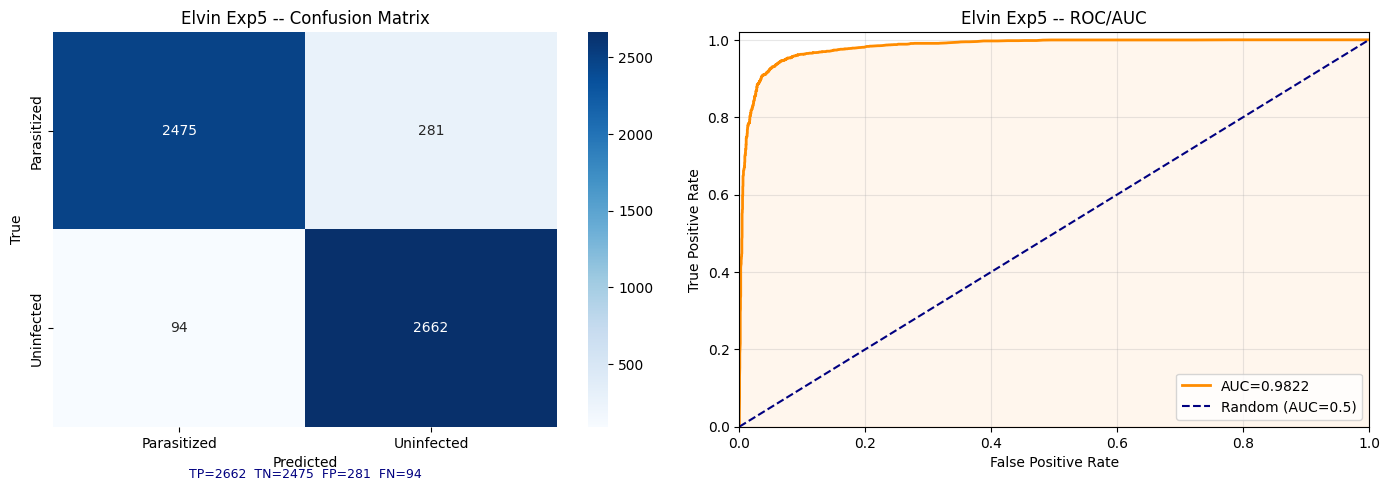

In [18]:
tg_aug, eg = make_resnet_generators(aug=True)
e5 = build_resnet50(0, 1e-4)
e5, he5 = train_or_load('E_exp5', e5, tg_aug, eg)
if he5: plot_learning_curves(he5, 'Elvin Exp5')
re5 = evaluate_model(e5, eg, 'Elvin Exp5')

### E_exp6 - Unfreeze 30 layers + augmentation, lr=1e-5

I combined moderate fine-tuning with augmentation so the features can adapt to malaria images while augmentation regularizes the head and I expected this combination to be the best performing experiment out of all seven.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 164s 422ms/step - accuracy: 0.8729 - loss: 0.3054 - val_accuracy: 0.9158 - val_loss: 0.2070 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 128s 369ms/step - accuracy: 0.9361 - loss: 0.1811 - val_accuracy: 0.9374 - val_loss: 0.1710 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 129s 375ms/step - accuracy: 0.9453 - loss: 0.1514 - val_accuracy: 0.9510 - val_loss: 0.1387 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 122s 353ms/step - accuracy: 0.9488 - loss: 0.1424 - val_accuracy: 0.9488 - val_loss: 0.1436 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 122s 353ms/step - accuracy: 0.9508 - loss: 0.1358 - val_accuracy: 0.9463 - val_loss: 0.1481 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9540 - loss: 0.1308
Epoch 6: ReduceLROnPlateau 

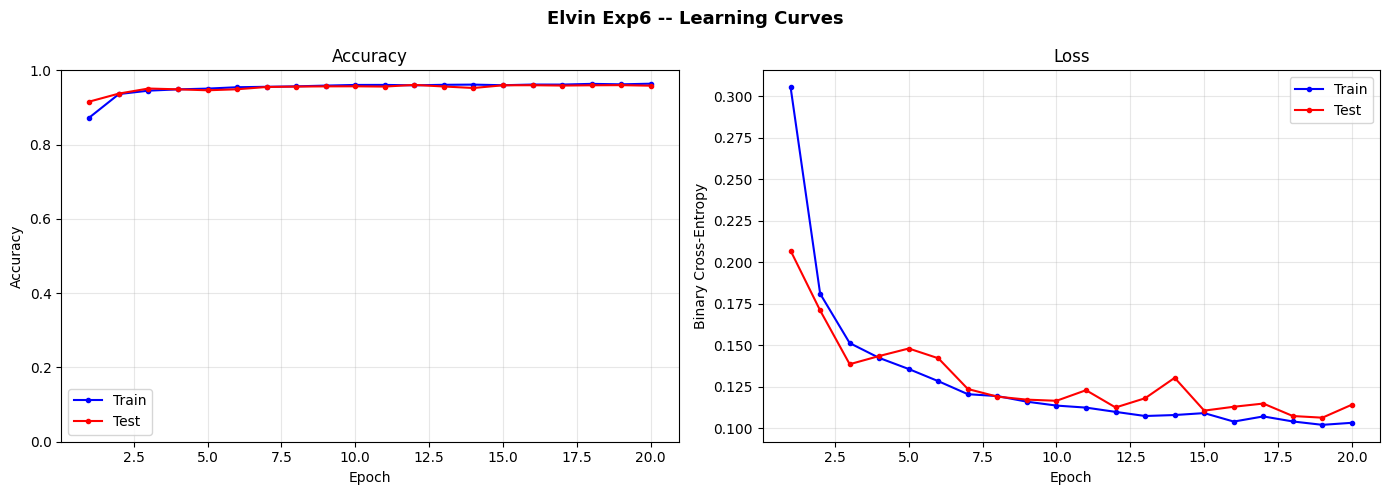


  Elvin Exp6
  Accuracy  : 0.9601
  Precision : 0.9481
  Recall    : 0.9735
  F1-Score  : 0.9606
  AUC       : 0.9929
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2756
  Uninfected       0.95      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



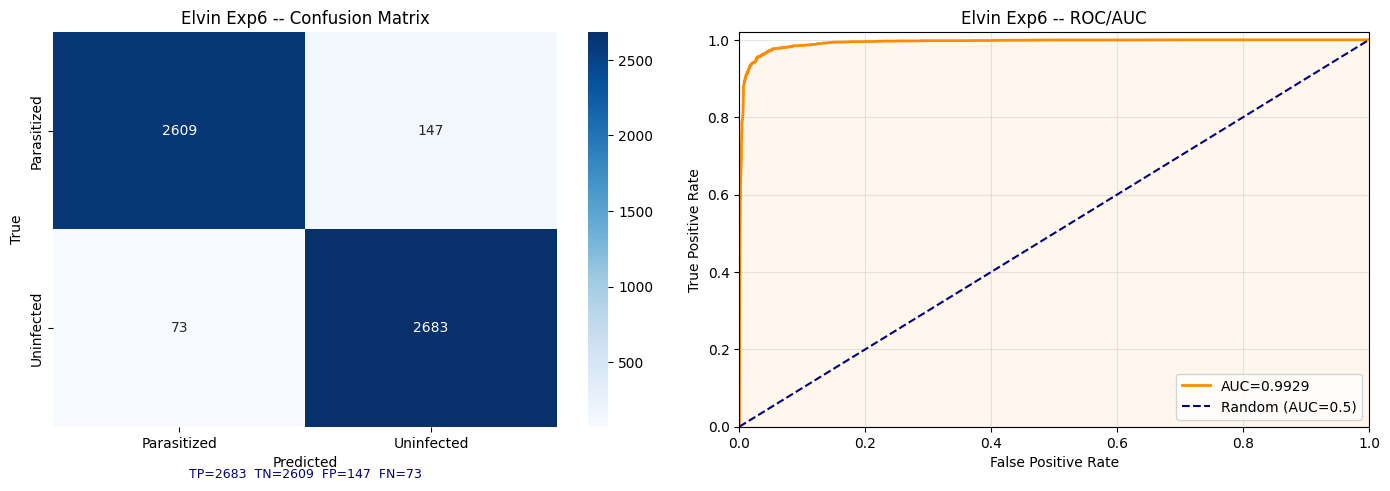

In [19]:
tg_aug, eg = make_resnet_generators(aug=True)
e6 = build_resnet50(30, 1e-5)
e6, he6 = train_or_load('E_exp6', e6, tg_aug, eg)
if he6: plot_learning_curves(he6, 'Elvin Exp6')
re6 = evaluate_model(e6, eg, 'Elvin Exp6')

### E_exp7 - Unfreeze 10 layers, ultra-low lr=5e-6

I halved the learning rate compared to Experiment 2 from 0.00001 to 0.000005 to test how sensitive ResNet fine-tuning is to the learning rate and if the results came out similar to Experiment 2 that would mean the exact value does not matter much at this scale.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 77s 178ms/step - accuracy: 0.7708 - loss: 0.5254 - val_accuracy: 0.9040 - val_loss: 0.2421 - learning_rate: 5.0000e-06
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.8889 - loss: 0.2723 - val_accuracy: 0.9198 - val_loss: 0.2127 - learning_rate: 5.0000e-06
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 47s 136ms/step - accuracy: 0.9119 - loss: 0.2279 - val_accuracy: 0.9269 - val_loss: 0.1979 - learning_rate: 5.0000e-06
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 45s 131ms/step - accuracy: 0.9213 - loss: 0.2045 - val_accuracy: 0.9345 - val_loss: 0.1826 - learning_rate: 5.0000e-06
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - accuracy: 0.9301 - loss: 0.1845 - val_accuracy: 0.9378 - val_loss: 0.1740 - learning_rate: 5.0000e-06
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9353 - loss: 0.1710 - val_accuracy: 0.9399 - val_lo

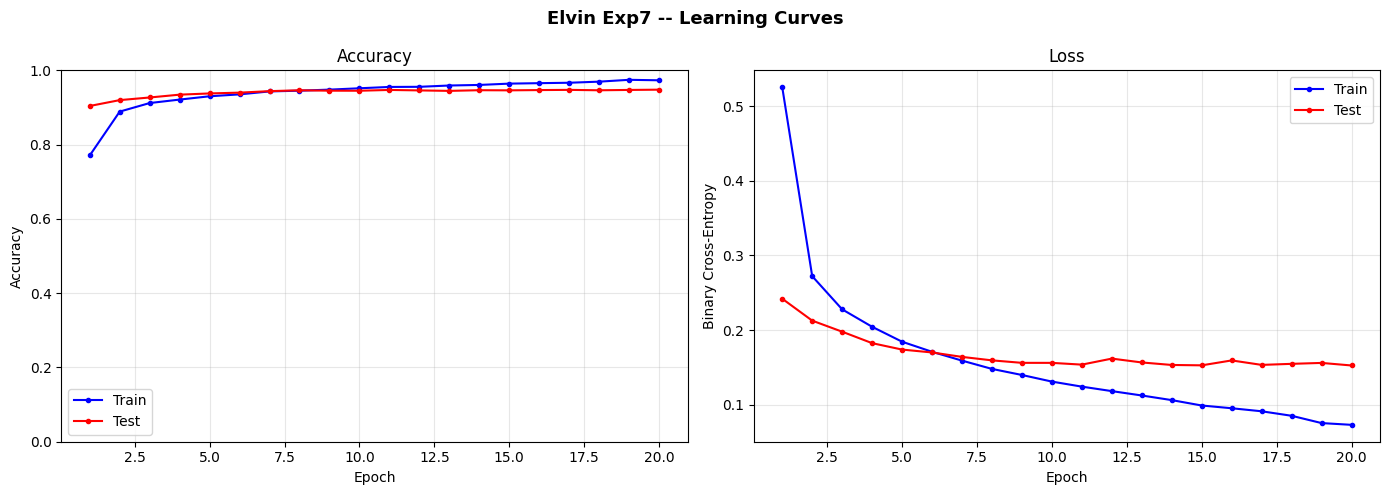


  Elvin Exp7
  Accuracy  : 0.9479
  Precision : 0.9420
  Recall    : 0.9546
  F1-Score  : 0.9483
  AUC       : 0.9873
              precision    recall  f1-score   support

 Parasitized       0.95      0.94      0.95      2756
  Uninfected       0.94      0.95      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



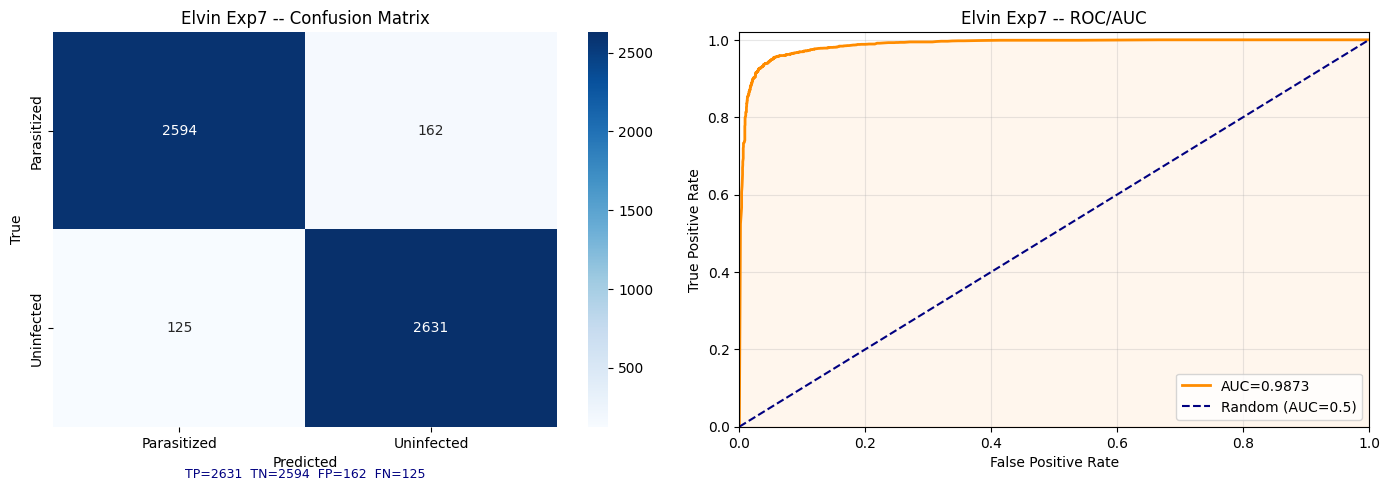

In [20]:
tg, eg = make_resnet_generators()
e7 = build_resnet50(10, 5e-6)
e7, he7 = train_or_load('E_exp7', e7, tg, eg)
if he7: plot_learning_curves(he7, 'Elvin Exp7')
re7 = evaluate_model(e7, eg, 'Elvin Exp7')

### Experiment Results

All seven experiments collected into the shared table format. F1 is used to pick the best because it balances precision and recall which is the right summary when both missed infections and false alarms carry cost.

In [21]:
elvin_res = [
    {'id':1,'desc':'ResNet50 frozen',**re1},
    {'id':2,'desc':'Unfreeze 10 lr=1e-5',**re2},
    {'id':3,'desc':'Unfreeze 30 lr=1e-5',**re3},
    {'id':4,'desc':'Unfreeze 50 lr=1e-5',**re4},
    {'id':5,'desc':'Frozen + aug',**re5},
    {'id':6,'desc':'Unfreeze 30 + aug',**re6},
    {'id':7,'desc':'Unfreeze 10 lr=5e-6',**re7},
]
print('ELVIN CYUBAHIRO -- ResNet50')
results_table(elvin_res)
best_e = max(elvin_res, key=lambda x: x['f1'])
print(f'Best: Exp {best_e["id"]} | F1={best_e["f1"]:.4f} | AUC={best_e["auc"]:.4f}')

ELVIN CYUBAHIRO -- ResNet50

 Exp | Description                         |    Acc |   Prec |    Rec |     F1 |    AUC
   1 | ResNet50 frozen                     | 0.9467 | 0.9480 | 0.9452 | 0.9466 | 0.9861
   2 | Unfreeze 10 lr=1e-5                 | 0.9479 | 0.9433 | 0.9532 | 0.9482 | 0.9869
   3 | Unfreeze 30 lr=1e-5                 | 0.9546 | 0.9459 | 0.9644 | 0.9551 | 0.9892
   4 | Unfreeze 50 lr=1e-5                 | 0.9621 | 0.9560 | 0.9688 | 0.9623 | 0.9920
   5 | Frozen + aug                        | 0.9320 | 0.9045 | 0.9659 | 0.9342 | 0.9822
   6 | Unfreeze 30 + aug                   | 0.9601 | 0.9481 | 0.9735 | 0.9606 | 0.9929
   7 | Unfreeze 10 lr=5e-6                 | 0.9479 | 0.9420 | 0.9546 | 0.9483 | 0.9873
Best: Exp 4 | F1=0.9623 | AUC=0.9920


### Error Analysis and Overfitting



Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Elvin (ResNet50) Best Exp 4
  Total misclassified : 209
  False Negatives (missed parasites) : 123
  False Positives (false alarms)     : 86


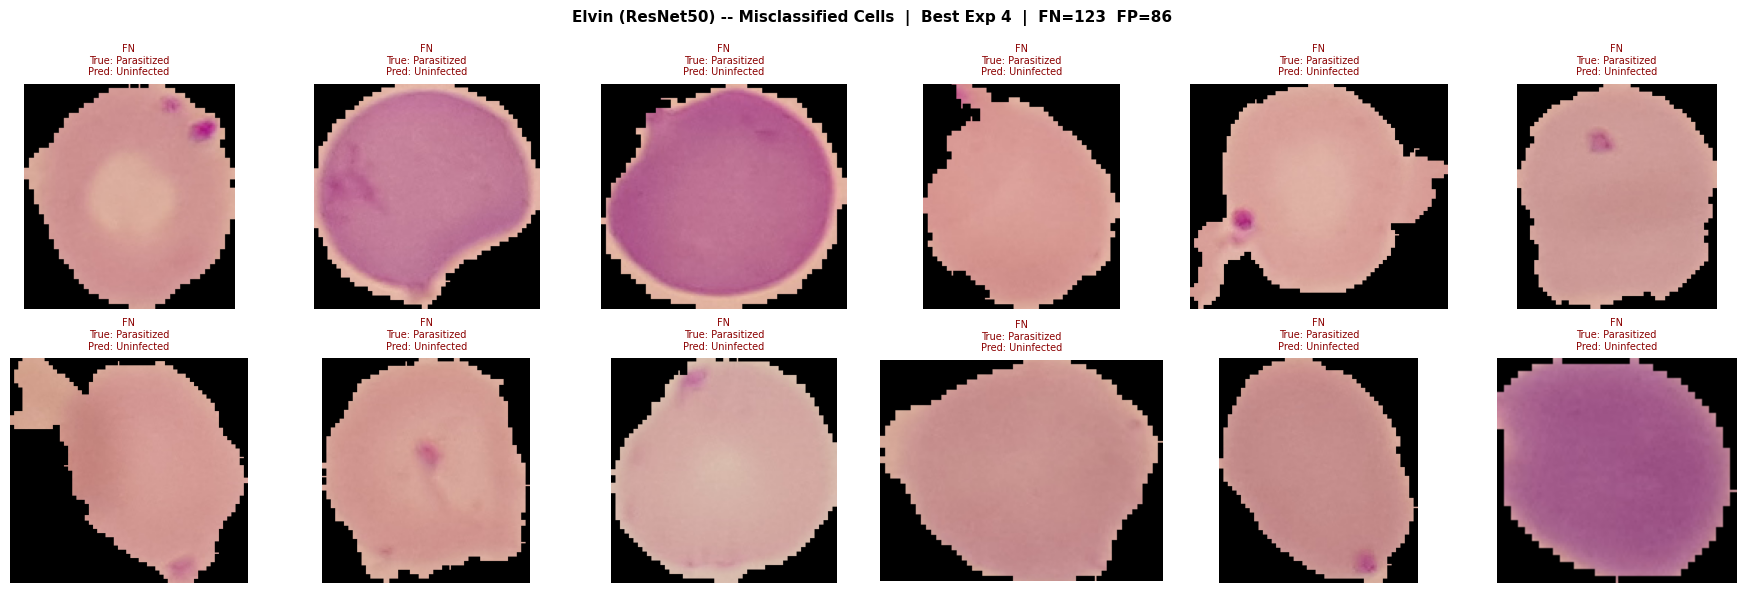

In [22]:
# Elvin — Error Analysis (best-experiment misclassification grid)
tg_tmp, eg_tmp = make_resnet_generators()
all_e_models = [e1, e2, e3, e4, e5, e6, e7]
bm_e = all_e_models[best_e['id'] - 1]
eg_tmp.reset()
probs_e_err = bm_e.predict(eg_tmp, verbose=0).flatten()
yp_e_err    = (probs_e_err >= 0.5).astype(int)
yt_e_err    = eg_tmp.classes
wrong_e     = np.where(yp_e_err != yt_e_err)[0]
fn_e = [idx for idx in wrong_e if yt_e_err[idx]==0 and yp_e_err[idx]==1]
fp_e = [idx for idx in wrong_e if yt_e_err[idx]==1 and yp_e_err[idx]==0]
print(f'Elvin (ResNet50) Best Exp {best_e["id"]}')
print(f'  Total misclassified : {len(wrong_e)}')
print(f'  False Negatives (missed parasites) : {len(fn_e)}')
print(f'  False Positives (false alarms)     : {len(fp_e)}')
cnames_e = list(eg_tmp.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(18, 6))
fig.suptitle(f'Elvin (ResNet50) -- Misclassified Cells  |  Best Exp {best_e["id"]}  |  FN={len(fn_e)}  FP={len(fp_e)}',
             fontsize=11, fontweight='bold')
for i_e, idx in enumerate(wrong_e[:12]):
    row, col = divmod(i_e, 6)
    axes[row, col].imshow(pyplot.imread(eg_tmp.filepaths[idx]))
    axes[row, col].axis('off')
    err_type = 'FN' if (yt_e_err[idx]==0 and yp_e_err[idx]==1) else 'FP'
    axes[row, col].set_title(
        f'{err_type}\nTrue: {cnames_e[yt_e_err[idx]]}\nPred: {cnames_e[yp_e_err[idx]]}',
        fontsize=7, color='darkred')
pyplot.tight_layout()
pyplot.savefig('Elvin_error_analysis.png', dpi=150, bbox_inches='tight')
pyplot.show()

### What I Found Across the Experiments

**Going through each run**

In Experiment 1 the whole ResNet50 backbone was frozen so only the head was training and there was not much overfitting risk because of the small number of trainable parameters but the model may have underfit a bit since ImageNet features are not specifically designed for the staining patterns in malaria microscopy images.

**Why I kept BatchNormalization frozen:** ResNet50 has many BatchNormalization layers that store the average and variance of activations learned from 1.2 million ImageNet images and if I unfroze them our small malaria dataset would recalculate those statistics and break the normalization making training unstable so keeping BN frozen while fine-tuning the conv layers is the right approach for ResNet.

**Experiments 2, 3 and 4 (unfreezing layers progressively):** As I unfroze more layers the model could shift more of its features toward the malaria domain and Experiment 3 with 30 layers was expected to be a good middle point. Experiment 4 with 50 layers carries more risk because if the learning rate is still too large for the lower layers the model might overwrite useful ImageNet features and validation accuracy could get worse than Experiment 3.

**Experiment 6 (30 layers with augmentation):** Combining moderate fine-tuning with augmentation was expected to give the best results because fine-tuning adapts the features and augmentation stops the head from overfitting the training images.

**Experiment 7 (10 layers, lr=5e-6):** I halved the learning rate compared to Experiment 2 to test whether even smaller weight updates make a difference when fine-tuning ResNet at this depth.

**Error Analysis:**

The images above show the cells that the best ResNet50 model got wrong. False Negatives are parasitized cells the model predicted as healthy and in a real clinical setting this would mean a patient does not get treatment which can be life threatening. False Positives mean the model flagged a healthy cell as parasitized which wastes resources but is the safer type of error and we compare these counts across all five group models in the final discussion.